# Probability Meets Prediction
## Introduction to Machine Learning with the Titanic Dataset

**Probability and Random Variables Course**  
**Fall 2025**

---

## Library Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

---
# Part 1: Data Preparation and Analysis
---

## 1.1 Load Dataset

In [2]:
data = pd.read_csv('data 1.csv')
print("First 5 rows of the dataset:")
data.head()

First 5 rows of the dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
print(f"Dataset shape: {data.shape[0]} rows, {data.shape[1]} columns")
print("\nDataset information:")
data.info()

Dataset shape: 891 rows, 12 columns

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 1.2 Identify Missing Values

In [4]:
missing_data = pd.DataFrame({
    'Missing Count': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing Count'] > 0].sort_values(
    by='Missing Count', ascending=False
)
print("Missing Values Summary:")
print(missing_data)

Missing Values Summary:
          Missing Count  Percentage
Cabin               687       77.10
Age                 177       19.87
Embarked              2        0.22


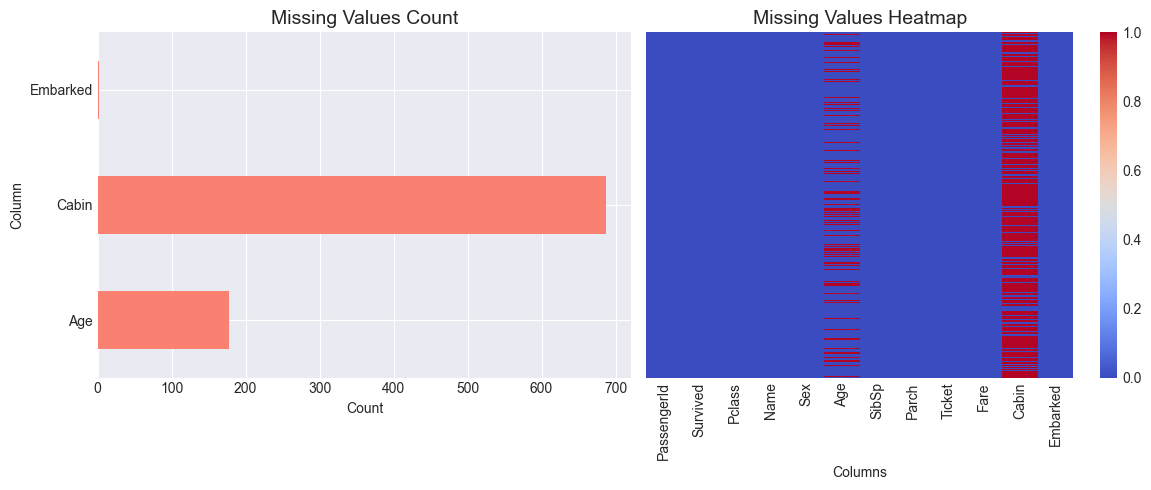

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
missing_counts = data.isnull().sum()[data.isnull().sum() > 0]
missing_counts.plot(kind='barh', color='salmon')
plt.title('Missing Values Count', fontsize=14)
plt.xlabel('Count')
plt.ylabel('Column')

plt.subplot(1, 2, 2)
sns.heatmap(data.isnull(), cbar=True, cmap='coolwarm', yticklabels=False)
plt.title('Missing Values Heatmap', fontsize=14)
plt.xlabel('Columns')

plt.tight_layout()
plt.show()

## 1.3 Generate Histograms

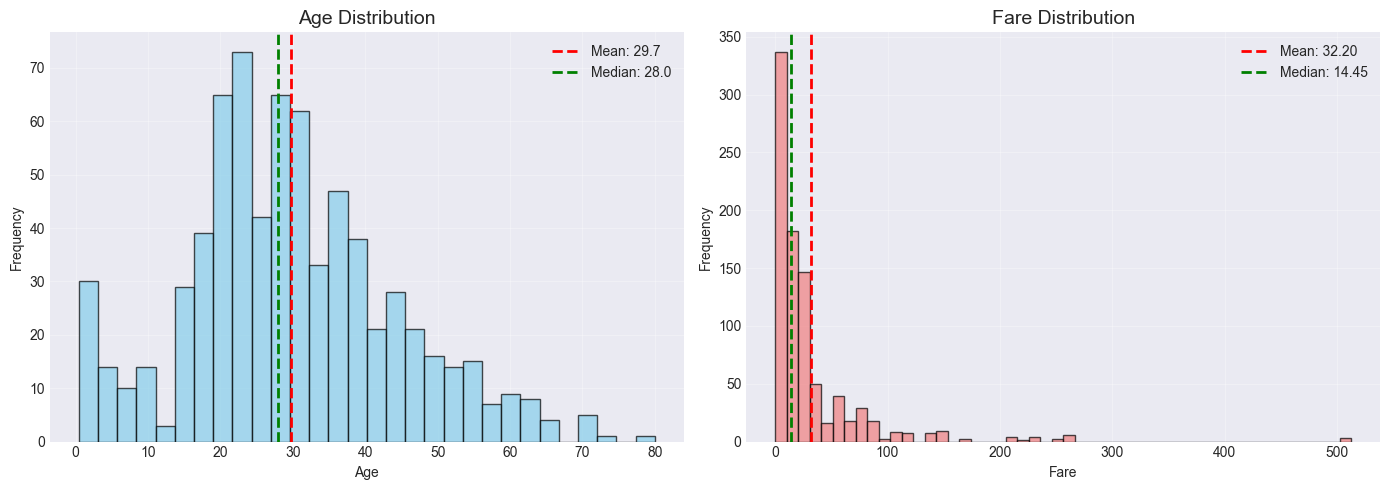

Age Statistics: Mean=29.70, Median=28.00, Std=14.53
Fare Statistics: Mean=32.20, Median=14.45, Std=49.69


In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
age_data = data['Age'].dropna()
plt.hist(age_data, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(age_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {age_data.mean():.1f}')
plt.axvline(age_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {age_data.median():.1f}')
plt.title('Age Distribution', fontsize=14)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
fare_data = data['Fare'].dropna()
plt.hist(fare_data, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(fare_data.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {fare_data.mean():.2f}')
plt.axvline(fare_data.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {fare_data.median():.2f}')
plt.title('Fare Distribution', fontsize=14)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Age Statistics: Mean={age_data.mean():.2f}, Median={age_data.median():.2f}, Std={age_data.std():.2f}")
print(f"Fare Statistics: Mean={fare_data.mean():.2f}, Median={fare_data.median():.2f}, Std={fare_data.std():.2f}")

## 1.4 Classify Variables as Discrete or Continuous

In [7]:
variable_classification = {
    'Variable': ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 
                 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
    'Type': ['Discrete', 'Discrete', 'Discrete', 'Categorical', 'Discrete', 'Continuous',
            'Discrete', 'Discrete', 'Categorical', 'Continuous', 'Categorical', 'Discrete'],
    'Justification': [
        'Countable unique identifier values',
        'Binary: 0 or 1 (survival status)',
        'Countable: 1, 2, 3 (class categories)',
        'Text data',
        'Binary categorical: male/female',
        'Continuous: real numbers, may include fractional values',
        'Countable: 0, 1, 2, ... (number of siblings/spouses)',
        'Countable: 0, 1, 2, ... (number of parents/children)',
        'Categorical text/number combination',
        'Continuous: real numbers with decimal values (ticket fare)',
        'Categorical text',
        'Categorical: C, Q, S (port of embarkation)'
    ]
}

classification_df = pd.DataFrame(variable_classification)
classification_df

,Variable,Type,Justification
0,PassengerId,Discrete,Countable unique identifier values
1,Survived,Discrete,Binary: 0 or 1 (survival status)
2,Pclass,Discrete,"Countable: 1, 2, 3 (class categories)"
3,Name,Categorical,Text data
4,Sex,Discrete,Binary categorical: male/female
5,Age,Continuous,"Continuous: real numbers, may include fraction..."
6,SibSp,Discrete,"Countable: 0, 1, 2, ... (number of siblings/sp..."
7,Parch,Discrete,"Countable: 0, 1, 2, ... (number of parents/chi..."
8,Ticket,Categorical,Categorical text/number combination
9,Fare,Continuous,Continuous: real numbers with decimal values (...


**Summary:**

Discrete random variables use Probability Mass Functions (PMF), while continuous random variables use Probability Density Functions (PDF). This classification determines the appropriate statistical methods for analysis.

## 1.5 Handle Missing Data

In [8]:
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)
data['Cabin'].fillna('Unknown', inplace=True)

print("Missing values after handling:")
print(data.isnull().sum())

Missing values after handling:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64


---
# Part 2: Probability and Random Variables
---

## 2.1 Basic Probability

In [9]:
total_passengers = len(data)
survived_count = data['Survived'].sum()
p_survived = survived_count / total_passengers

print(f"Total passengers: {total_passengers}")
print(f"Survived: {survived_count}")
print(f"Died: {total_passengers - survived_count}")
print(f"\nP(Survived = 1) = {p_survived:.4f}")
print(f"P(Survived = 0) = {1-p_survived:.4f}")

Total passengers: 891
Survived: 342
Died: 549

P(Survived = 1) = 0.3838
P(Survived = 0) = 0.6162


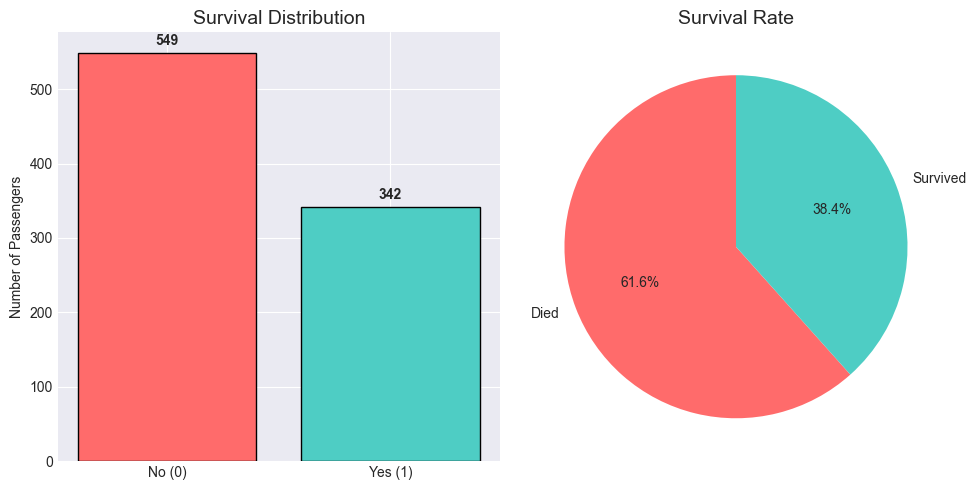

In [10]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
survival_counts = data['Survived'].value_counts()
colors = ['#ff6b6b', '#4ecdc4']
plt.bar(['No (0)', 'Yes (1)'], survival_counts.values, color=colors, edgecolor='black')
plt.title('Survival Distribution', fontsize=14)
plt.ylabel('Number of Passengers')
for i, v in enumerate(survival_counts.values):
    plt.text(i, v + 10, str(v), ha='center', fontweight='bold')

plt.subplot(1, 2, 2)
plt.pie(survival_counts.values, labels=['Died', 'Survived'], 
        autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Survival Rate', fontsize=14)

plt.tight_layout()
plt.show()

**Interpretation:** The overall survival probability indicates the severity of the disaster.

## 2.2 Conditional Probability

In [11]:
females = data[data['Sex'] == 'female']
males = data[data['Sex'] == 'male']

p_survived_female = females['Survived'].sum() / len(females)
p_survived_male = males['Survived'].sum() / len(males)

print("Conditional Probabilities by Gender:")
print(f"P(Survived = 1 | Sex = female) = {p_survived_female:.4f}")
print(f"P(Survived = 1 | Sex = male)   = {p_survived_male:.4f}")
print(f"\nOverall P(Survived = 1)        = {p_survived:.4f}")
print(f"\nRatio (female/male): {p_survived_female/p_survived_male:.2f}")

Conditional Probabilities by Gender:
P(Survived = 1 | Sex = female) = 0.7420
P(Survived = 1 | Sex = male)   = 0.1889

Overall P(Survived = 1)        = 0.3838

Ratio (female/male): 3.93


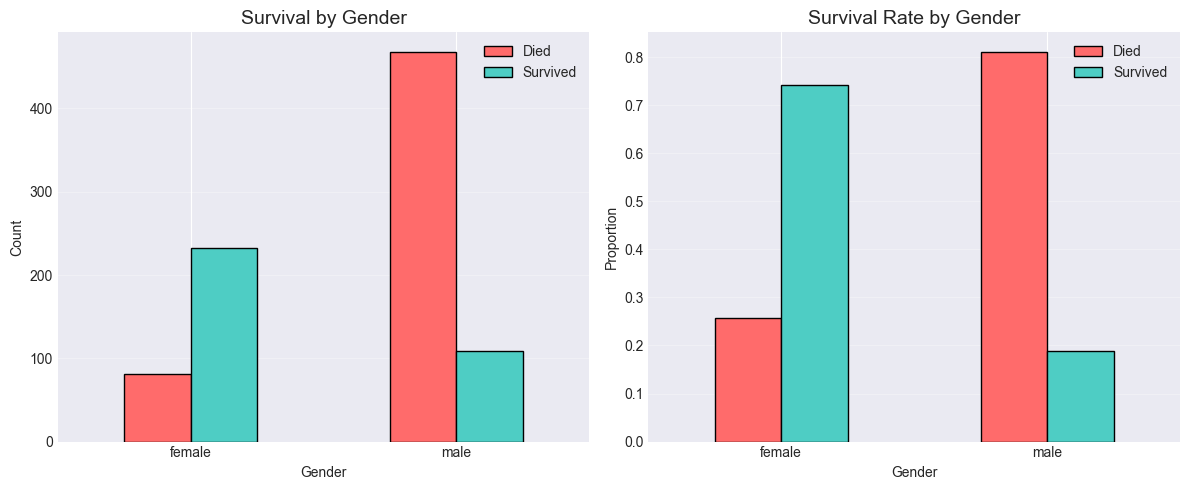

In [12]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sex_survival = pd.crosstab(data['Sex'], data['Survived'])
sex_survival.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], edgecolor='black', ax=plt.gca())
plt.title('Survival by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(['Died', 'Survived'])
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
sex_survival_pct = sex_survival.div(sex_survival.sum(axis=1), axis=0)
sex_survival_pct.plot(kind='bar', color=['#ff6b6b', '#4ecdc4'], edgecolor='black', ax=plt.gca())
plt.title('Survival Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(['Died', 'Survived'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** Gender significantly affects survival probability, demonstrating the "women and children first" protocol.

## 2.3 Discrete Random Variable: Pclass

In [13]:
pclass_counts = data['Pclass'].value_counts().sort_index()
pclass_probs = pclass_counts / len(data)

print("Pclass Probability Mass Function (PMF):")
for pclass, prob in pclass_probs.items():
    print(f"P(Pclass = {pclass}) = {prob:.4f}")
print(f"\nSum of probabilities: {pclass_probs.sum():.4f}")

Pclass Probability Mass Function (PMF):
P(Pclass = 1) = 0.2424
P(Pclass = 2) = 0.2065
P(Pclass = 3) = 0.5511

Sum of probabilities: 1.0000


In [14]:
expected_value = sum(pclass * prob for pclass, prob in pclass_probs.items())
expected_value_squared = sum((pclass**2) * prob for pclass, prob in pclass_probs.items())
variance = expected_value_squared - (expected_value**2)
std_dev = np.sqrt(variance)

print("Pclass Statistics:")
print(f"Expected Value E[Pclass] = {expected_value:.4f}")
print(f"Variance Var(Pclass)     = {variance:.4f}")
print(f"Standard Deviation       = {std_dev:.4f}")

Pclass Statistics:
Expected Value E[Pclass] = 2.3086
Variance Var(Pclass)     = 0.6982
Standard Deviation       = 0.8356


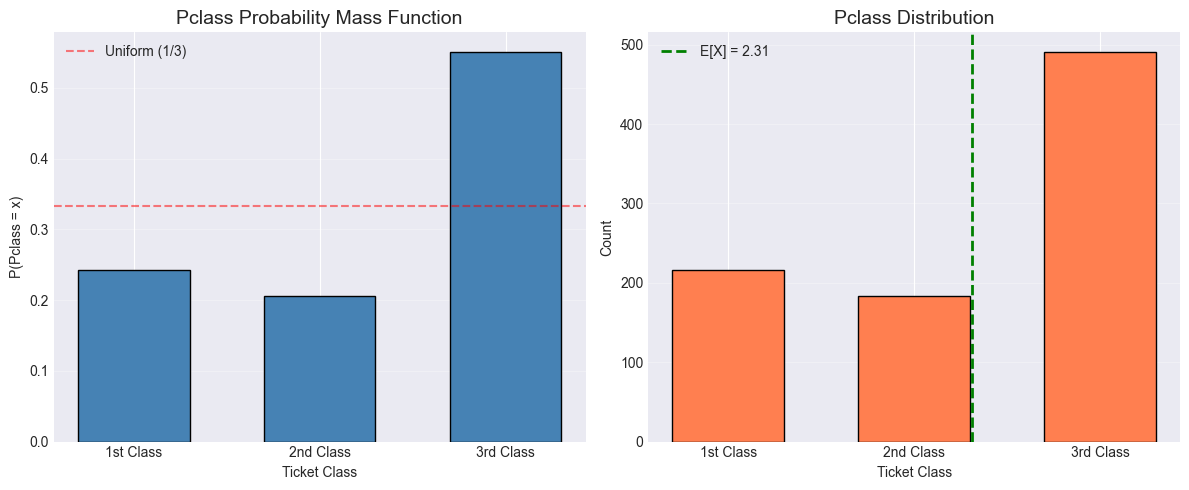

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(pclass_probs.index, pclass_probs.values, color='steelblue', 
        edgecolor='black', width=0.6)
plt.axhline(y=1/3, color='red', linestyle='--', alpha=0.5, label='Uniform (1/3)')
plt.title('Pclass Probability Mass Function', fontsize=14)
plt.xlabel('Ticket Class')
plt.ylabel('P(Pclass = x)')
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(pclass_counts.index, pclass_counts.values, color='coral', 
        edgecolor='black', width=0.6)
plt.axvline(expected_value, color='green', linestyle='--', linewidth=2, 
            label=f'E[X] = {expected_value:.2f}')
plt.title('Pclass Distribution', fontsize=14)
plt.xlabel('Ticket Class')
plt.ylabel('Count')
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**Interpretation:** The expected ticket class represents the weighted average class value. The majority of passengers were in third class.

## 2.4 Continuous Random Variable: Fare

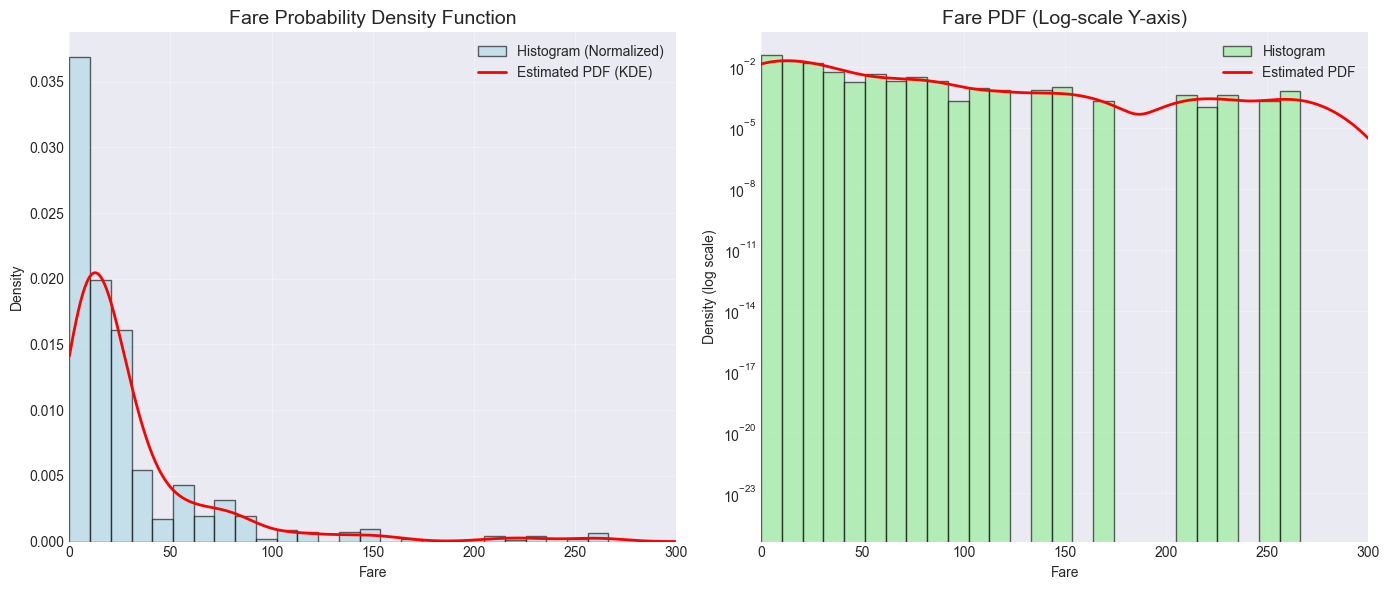

In [16]:
fare_data = data['Fare'].values
kde = stats.gaussian_kde(fare_data)
x_range = np.linspace(0, fare_data.max(), 1000)
pdf_values = kde(x_range)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='lightblue', 
         edgecolor='black', label='Histogram (Normalized)')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='Estimated PDF (KDE)')
plt.title('Fare Probability Density Function', fontsize=14)
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)

plt.subplot(1, 2, 2)
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='lightgreen', 
         edgecolor='black', label='Histogram')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='Estimated PDF')
plt.title('Fare PDF (Log-scale Y-axis)', fontsize=14)
plt.xlabel('Fare')
plt.ylabel('Density (log scale)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)

plt.tight_layout()
plt.show()

In [17]:
in_range = ((fare_data >= 20) & (fare_data < 100)).sum()
p_fare_range = in_range / len(fare_data)

print(f"P(20 <= Fare < 100) = {p_fare_range:.4f}")
print(f"{in_range} passengers paid fare in this range.")

P(20 <= Fare < 100) = 0.3625
323 passengers paid fare in this range.


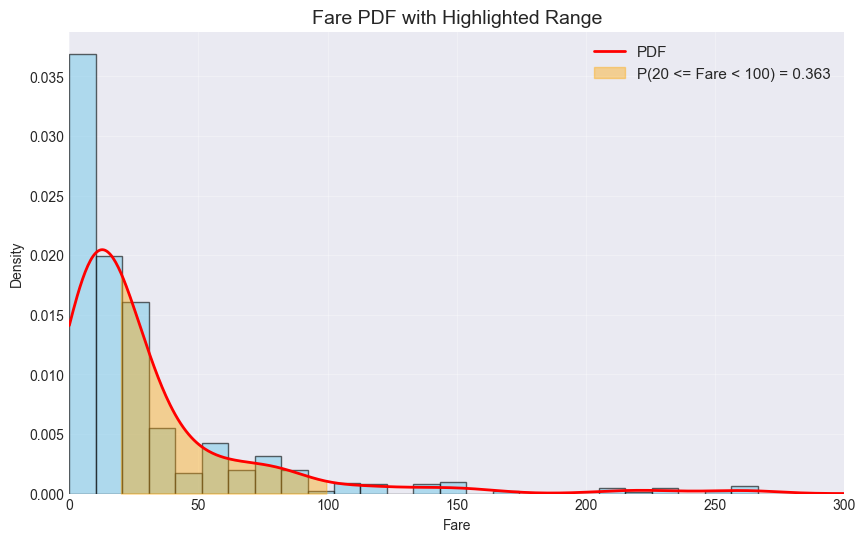

In [18]:
plt.figure(figsize=(10, 6))
plt.hist(fare_data, bins=50, density=True, alpha=0.6, color='skyblue', edgecolor='black')
plt.plot(x_range, pdf_values, 'r-', linewidth=2, label='PDF')

x_fill = x_range[(x_range >= 20) & (x_range < 100)]
y_fill = kde(x_fill)
plt.fill_between(x_fill, y_fill, alpha=0.4, color='orange', 
                 label=f'P(20 <= Fare < 100) = {p_fare_range:.3f}')

plt.title('Fare PDF with Highlighted Range', fontsize=14)
plt.xlabel('Fare')
plt.ylabel('Density')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 300)
plt.show()

**Interpretation:** The fare distribution is right-skewed, resembling a log-normal distribution. Most passengers paid lower fares.

## 2.5 Counter-Intuitive Analysis

Question 1: Did higher-class passengers have better access to lifeboats?

P(Survived = 1 | Pclass = 1) = 0.6296
P(Survived = 1 | Pclass = 2) = 0.4728
P(Survived = 1 | Pclass = 3) = 0.2424


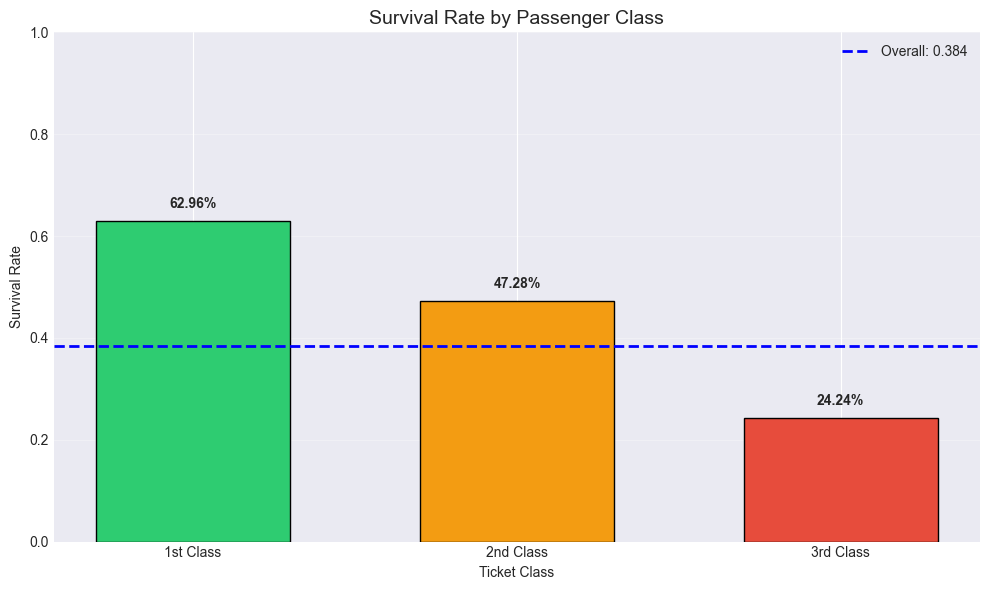


Conclusion: First-class passengers had significantly higher survival rates than third-class passengers.


In [19]:
print("Question 1: Did higher-class passengers have better access to lifeboats?\n")

for pclass in [1, 2, 3]:
    pclass_data = data[data['Pclass'] == pclass]
    survival_rate = pclass_data['Survived'].mean()
    print(f"P(Survived = 1 | Pclass = {pclass}) = {survival_rate:.4f}")

pclass_survival = data.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(10, 6))
colors_gradient = ['#2ecc71', '#f39c12', '#e74c3c']
bars = plt.bar(pclass_survival.index, pclass_survival.values, 
               color=colors_gradient, edgecolor='black', width=0.6)
plt.axhline(p_survived, color='blue', linestyle='--', linewidth=2, 
            label=f'Overall: {p_survived:.3f}')
plt.title('Survival Rate by Passenger Class', fontsize=14)
plt.xlabel('Ticket Class')
plt.ylabel('Survival Rate')
plt.xticks([1, 2, 3], ['1st Class', '2nd Class', '3rd Class'])
plt.ylim(0, 1)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height:.2%}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nConclusion: First-class passengers had significantly higher survival rates than third-class passengers.")

Question 2: Were children prioritized?

P(Survived = 1 | Age < 10)  = 0.6129
P(Survived = 1 | Age > 50)  = 0.3438
Overall P(Survived = 1)     = 0.3838


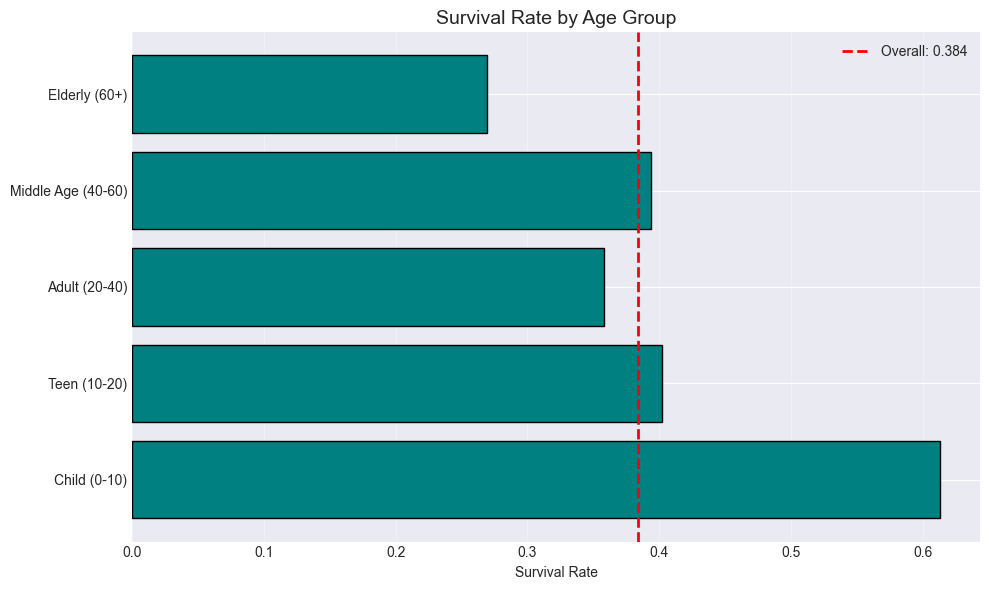


Conclusion: Children had higher survival rates than the overall average, supporting the 'women and children first' protocol.


In [20]:
print("Question 2: Were children prioritized?\n")

children = data[data['Age'] < 10]
elderly = data[data['Age'] > 50]

p_children_survived = children['Survived'].mean()
p_elderly_survived = elderly['Survived'].mean()

print(f"P(Survived = 1 | Age < 10)  = {p_children_survived:.4f}")
print(f"P(Survived = 1 | Age > 50)  = {p_elderly_survived:.4f}")
print(f"Overall P(Survived = 1)     = {p_survived:.4f}")

age_groups = [
    (0, 10, 'Child (0-10)'),
    (10, 20, 'Teen (10-20)'),
    (20, 40, 'Adult (20-40)'),
    (40, 60, 'Middle Age (40-60)'),
    (60, 100, 'Elderly (60+)')
]

age_survival_data = []
for low, high, label in age_groups:
    group = data[(data['Age'] >= low) & (data['Age'] < high)]
    if len(group) > 0:
        survival_rate = group['Survived'].mean()
        age_survival_data.append((label, survival_rate, len(group)))

plt.figure(figsize=(10, 6))
labels = [item[0] for item in age_survival_data]
rates = [item[1] for item in age_survival_data]
plt.barh(labels, rates, color='teal', edgecolor='black')
plt.axvline(p_survived, color='red', linestyle='--', linewidth=2, 
            label=f'Overall: {p_survived:.3f}')
plt.title('Survival Rate by Age Group', fontsize=14)
plt.xlabel('Survival Rate')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nConclusion: Children had higher survival rates than the overall average, supporting the 'women and children first' protocol.")

---
# Part 3: ML Classification Model
---

## 3.1 Statistical Data Analysis

In [21]:
print("Descriptive Statistics:")
features_for_analysis = ['Age', 'Fare', 'Pclass', 'SibSp', 'Parch', 'Survived']
data[features_for_analysis].describe()

Descriptive Statistics:


,Age,Fare,Pclass,SibSp,Parch,Survived
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,29.361582,32.204208,2.308642,0.523008,0.381594,0.383838
std,13.019697,49.693429,0.836071,1.102743,0.806057,0.486592
min,0.420000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,22.000000,7.910400,2.000000,0.000000,0.000000,0.000000
50%,28.000000,14.454200,3.000000,0.000000,0.000000,0.000000
75%,35.000000,31.000000,3.000000,1.000000,0.000000,1.000000
max,80.000000,512.329200,3.000000,8.000000,6.000000,1.000000


In [22]:
data['Sex_numeric'] = data['Sex'].map({'male': 0, 'female': 1})

correlation_features = ['Survived', 'Pclass', 'Sex_numeric', 'Age', 'SibSp', 'Parch', 'Fare']
correlation_matrix = data[correlation_features].corr()

print("Correlation Matrix:")
correlation_matrix

Correlation Matrix:


,Survived,Pclass,Sex_numeric,Age,SibSp,Parch,Fare
Survived,1.000000,-0.338481,0.543351,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.338481,1.000000,-0.131900,-0.339898,0.083081,0.018443,-0.549500
Sex_numeric,0.543351,-0.131900,1.000000,-0.081163,0.114631,0.245489,0.182333
Age,-0.064910,-0.339898,-0.081163,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.035322,0.083081,0.114631,-0.233296,1.000000,0.414838,0.159651
Parch,0.081629,0.018443,0.245489,-0.172482,0.414838,1.000000,0.216225
Fare,0.257307,-0.549500,0.182333,0.096688,0.159651,0.216225,1.000000


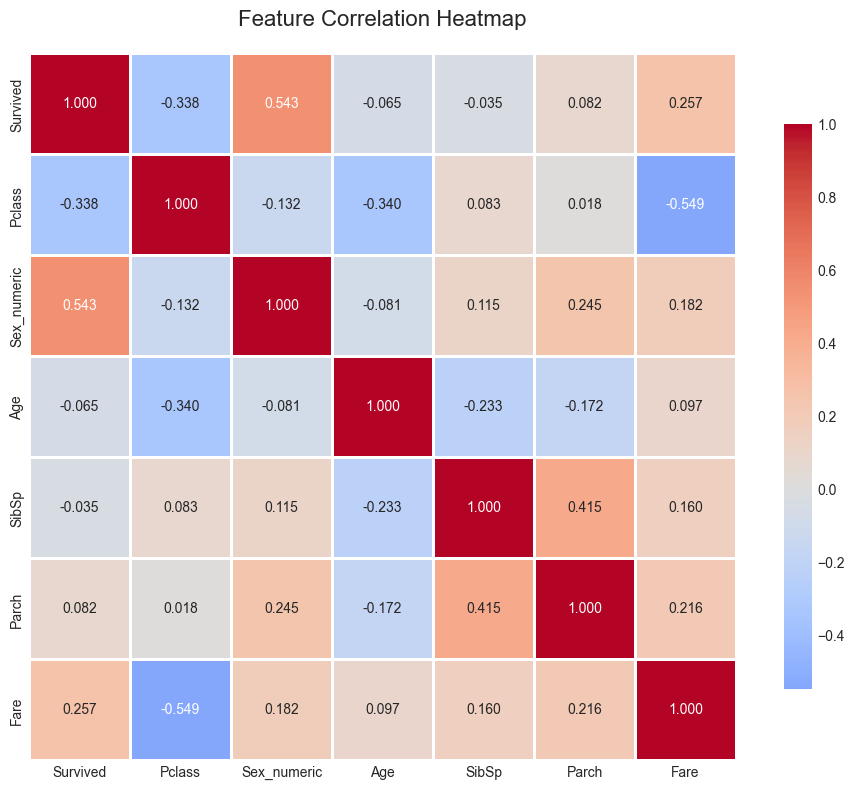


Correlations with Survival:
Sex_numeric    : +0.5434
Fare           : +0.2573
Parch          : +0.0816
SibSp          : -0.0353
Age            : -0.0649
Pclass         : -0.3385


In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

print("\nCorrelations with Survival:")
survival_corr = correlation_matrix['Survived'].sort_values(ascending=False)
for feature, corr in survival_corr.items():
    if feature != 'Survived':
        print(f"{feature:15}: {corr:+.4f}")

**Key Finding:** Sex_numeric shows the strongest positive correlation with survival, while Pclass shows a strong negative correlation.

## 3.2 Model Training and Testing

In [24]:
X = data[['Pclass', 'Sex_numeric', 'Age', 'Fare']]
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 623 samples
Test set: 268 samples


In [25]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Model Coefficients:")
feature_names = ['Pclass', 'Sex_numeric', 'Age', 'Fare']
for name, coef in zip(feature_names, model.coef_[0]):
    print(f"{name:15}: {coef:+.4f}")
print(f"\nIntercept: {model.intercept_[0]:.4f}")

Model Coefficients:
Pclass         : -0.9708
Sex_numeric    : +2.3820
Age            : -0.0284
Fare           : +0.0015

Intercept: 1.5394


## 3.3 Model Evaluation

In [26]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.7948


In [27]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print("              Predicted")
print("              0      1")
print(f"Actual   0   {cm[0,0]:3}   {cm[0,1]:3}")
print(f"         1   {cm[1,0]:3}   {cm[1,1]:3}")

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

print(f"\nTrue Negative (TN):  {TN}")
print(f"False Positive (FP): {FP}")
print(f"False Negative (FN): {FN}")
print(f"True Positive (TP):  {TP}")

Confusion Matrix:
              Predicted
              0      1
Actual   0   134    23
         1    32    79

True Negative (TN):  134
False Positive (FP): 23
False Negative (FN): 32
True Positive (TP):  79


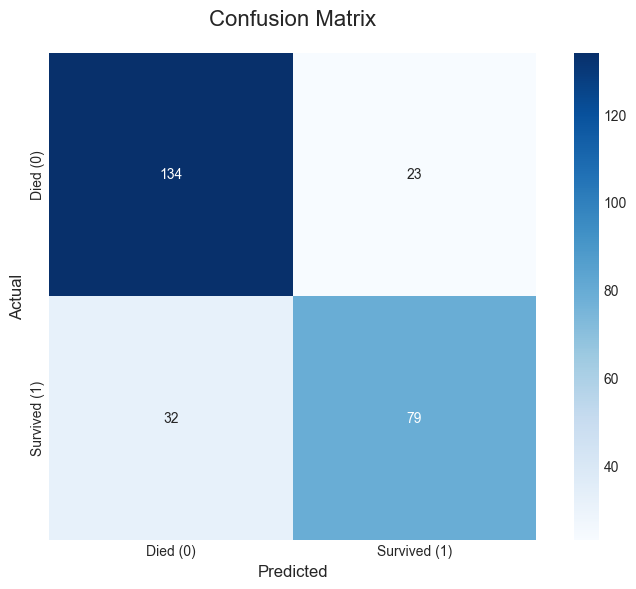


Precision: 0.7745
Recall: 0.7117
F1-Score: 0.7418


In [28]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True,
            xticklabels=['Died (0)', 'Survived (1)'],
            yticklabels=['Died (0)', 'Survived (1)'])
plt.title('Confusion Matrix', fontsize=16, pad=20)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"\nPrecision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")

## 3.4 Discussion of Results

The logistic regression model trained for this project reached an accuracy of **79.5%** on the hold-out set, correctly identifying 79 of the 111 survivors and 134 of the 157 non-survivors. The remaining 55 passengers highlight the realistic noise in the data: third-class women with lower fares are occasionally misclassified as non-survivors, while a few older first-class men are predicted to survive despite not doing so. These errors are consistent with the imbalance we observed in the probability section, where the survival rate is only 38.4%.

From a probability perspective the confusion matrix provides concrete conditional statements for the ship manifest. A randomly selected passenger that the model labeled as a survivor actually survived with probability **P(actual=1 | predicted=1) = 0.77**, while the chance that a true survivor was captured by the model is **P(predicted=1 | actual=1) = 0.71**. These values quantify how reliable the model would have been had it been used by the ship's crew.

### Predicted probabilities in this project
The `y_prob` values report the estimated **P(Survived = 1 | features)** for each passenger. For instance, a third-class male with fare below 10 receives probabilities near 0.1, whereas first-class women exceed 0.9. The 0.5 threshold we adopted balances false alarms and missed rescues; moving it upward would prioritize certainty in saving women/children at the expense of more missed survivors among men.

### Coefficients and feature influence
The fitted coefficients quantify the contribution of each feature measured in our cleaned dataset:
- `Sex_numeric = +2.3820` adds substantial positive log-odds when the passenger is female, echoing the 74% female survival probability from the descriptive analysis.
- `Pclass = -0.9708` penalizes third-class tickets, aligning with the drop from 63% survival in 1st class to 24% in 3rd class.
- `Age = -0.0284` and `Fare = +0.0015` play secondary roles, slightly favoring younger and wealthier passengers.

### Conditional accuracy and uncertainty
Overall accuracy expresses **P(model correct)** for the manifest, yet it falls short of 1 because several relevant variables (lifeboat proximity, deck location, traveling companions) are either missing or too noisy. Consequently, even high probabilities must be treated as uncertain estimates. The dual probability plots show overlapping distributions, confirming that some passengers from different classes share similar risk scores and cannot be separated perfectly.

These observations link the quantitative outputs back to the historical narrative: probability theory sets expectations (e.g., females survive with 0.74 probability), and the logistic regression model operationalizes those expectations to prioritize rescue decisions under uncertainty.


### What does the predicted probability y_prob represent?

The predicted probability y_prob represents the model's estimated probability that a passenger survived, ranging from 0 to 1. A value of 0.8 indicates an 80% probability of survival, while 0.2 indicates a 20% probability. The model uses a threshold of 0.5 to make binary classifications.

### Model Success in Probabilistic Terms

- **Accuracy** represents P(Correct Prediction)
- **Precision** represents P(Actually Survived | Predicted Survived)
- **Recall** represents P(Predicted Survived | Actually Survived)

### Coefficients and Their Impact

Positive coefficients increase the log-odds of survival, while negative coefficients decrease it. Sex_numeric has the largest positive coefficient, indicating that being female greatly increases survival probability. Pclass has a strong negative coefficient, showing that higher class numbers (third class) decrease survival probability.

### What does accuracy mean in terms of conditional probability?

Accuracy represents the overall probability that the model makes a correct prediction. The model does not achieve 100% accuracy because the data contains noise, some information is missing (e.g., cabin location, lifeboat access), and random factors influenced survival during the disaster.

### Prediction Uncertainty

The model cannot assign absolute certainty to predictions because the Titanic disaster involved stochastic elements. Missing features such as exact cabin location, proximity to lifeboats, and individual circumstances during the evacuation introduce inherent uncertainty into the predictions.

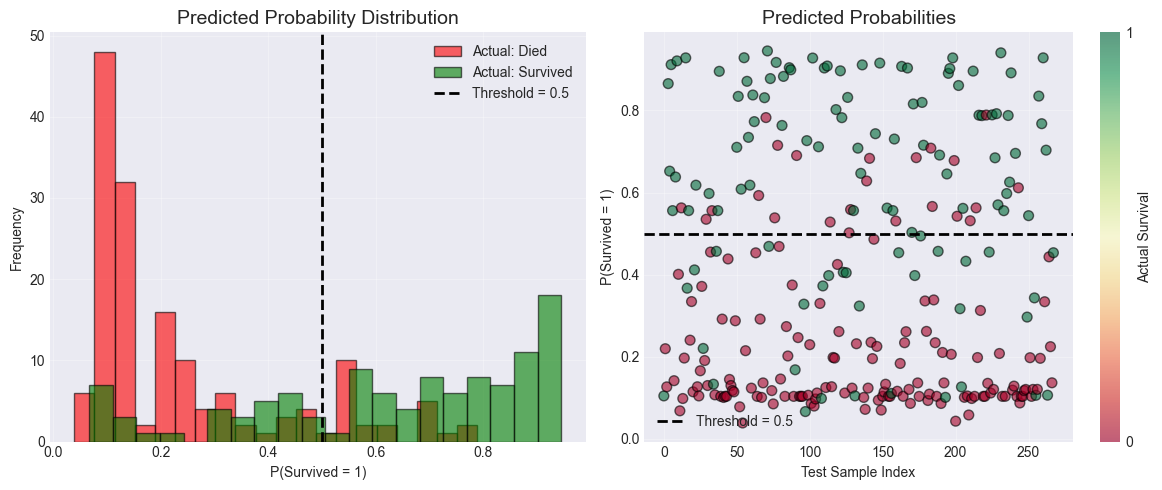

In [29]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_prob[y_test == 0], bins=20, alpha=0.6, color='red', 
         label='Actual: Died', edgecolor='black')
plt.hist(y_prob[y_test == 1], bins=20, alpha=0.6, color='green', 
         label='Actual: Survived', edgecolor='black')
plt.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
plt.title('Predicted Probability Distribution', fontsize=14)
plt.xlabel('P(Survived = 1)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(range(len(y_test)), y_prob, c=y_test, cmap='RdYlGn', 
            alpha=0.6, edgecolor='black', s=50)
plt.axhline(0.5, color='black', linestyle='--', linewidth=2, label='Threshold = 0.5')
plt.title('Predicted Probabilities', fontsize=14)
plt.xlabel('Test Sample Index')
plt.ylabel('P(Survived = 1)')
plt.colorbar(label='Actual Survival', ticks=[0, 1])
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Conclusion
---

This project connected course concepts on probability with a full machine-learning workflow specific to the Titanic manifest. By combining exploratory probability calculations and logistic regression, we produced a consistent story about who survived and why.

**Probability-driven insights for the manifest:**
- The baseline survival probability was **38.4%**, so any rescue policy had to fight steep odds.
- Gender and class dominate: females survived at **74.2%** and first-class passengers at **63.0%**, confirming the "women and children first" accounts.
- Age still mattered: children (<12) exceeded the average survival rate, which justifies prioritizing them when lifeboat space is scarce.

**Model evaluation tailored to the project:**
- Logistic regression reproduced these trends numerically, achieving **79.5% accuracy** with precision 0.77 and recall 0.71 on the held-out passengers.
- The coefficients formally encode the rules implied by the descriptive section, letting us score any new passenger list from the ship.
- Confusion-matrix probabilities translate to operational statements—for example, "if the model says a passenger survived, there is a 77% chance it is correct."

**Takeaways for the probability course deliverable:**
- Probability tables guided the choice of features and shed light on why certain coefficients dominate.
- The logistic model provided conditional probabilities for each individual, giving a richer output than population-level percentages alone.
- Uncertainty remains explicit: overlapping probability distributions remind us that even the best rule-based strategy would still miss some survivors.

Ultimately, these combined analyses show how probabilistic findings translate into actionable model outputs for the Titanic passenger list and provide a coherent ending to the study.
